<a href="https://colab.research.google.com/github/chilakala-jahnavi/Customer_Segmentation_and_CLV_Analysis/blob/main/Customer_Segmentation_%26_CLV_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
#load the dataset
df = pd.read_csv("/content/sample_data/digital_wallet_ltv_dataset.csv")

In [8]:
# Display the first five records to understand the dataset structure
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [9]:
# Check the number of rows and columns in the dataset
df.shape

(7000, 20)

In [10]:
# Display all column names available in the dataset
df.columns

Index(['Customer_ID', 'Age', 'Location', 'Income_Level', 'Total_Transactions',
       'Avg_Transaction_Value', 'Max_Transaction_Value',
       'Min_Transaction_Value', 'Total_Spent', 'Active_Days',
       'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned', 'Referral_Count',
       'Cashback_Received', 'App_Usage_Frequency', 'Preferred_Payment_Method',
       'Support_Tickets_Raised', 'Issue_Resolution_Time',
       'Customer_Satisfaction_Score', 'LTV'],
      dtype='object')

In [11]:
# Examine data types, non-null values, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   object 
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   object 
 3   Income_Level                 7000 non-null   object 
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received 

In [12]:
# Generate descriptive statistics for numerical features
df.describe()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831482,30159.596784,2981.549953,5.002022e+06,181.934857,183.847714,2501.545429,24.837000,2496.525032,10.017571,36.528007,5.479000,5.119197e+05
std,15.516036,286.277311,5780.880831,21996.108793,2197.342161,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651412,6.037067,20.389399,2.860197,4.390551e+05
min,16.000000,1.000000,10.185827,31.857484,4.617966,1.498144e+03,1.000000,1.000000,0.000000,0.000000,0.234349,0.000000,1.019853,1.000000,3.770495e+03
25%,29.000000,252.000000,4907.466790,12224.329366,1233.066226,1.363991e+06,90.000000,93.000000,1254.750000,12.000000,1269.423703,5.000000,19.127302,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.172643,25469.392130,2473.181073,3.756105e+06,182.000000,184.000000,2466.000000,25.000000,2478.943350,10.000000,36.257396,5.000000,3.878180e+05
75%,56.000000,744.000000,14955.048801,44515.414177,4378.759195,7.645508e+06,273.000000,275.000000,3792.250000,37.000000,3749.375251,15.000000,54.068594,8.000000,7.748578e+05
max,69.000000,1000.000000,19996.445086,98809.241533,9917.028823,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.698480,20.000000,71.978946,10.000000,1.956988e+06


In [13]:
# Check for missing values in each column
df.isnull().sum()

,0
Customer_ID,0
Age,0
Location,0
Income_Level,0
Total_Transactions,0
Avg_Transaction_Value,0
Max_Transaction_Value,0
Min_Transaction_Value,0
Total_Spent,0
Active_Days,0


In [14]:
df = df.dropna()

In [15]:
df

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,cust_6995,68,Suburban,High,340,162.703503,605.997495,80.352666,5.531919e+04,78,20,521,32,654.218655,Monthly,Credit Card,14,3.351374,3,1.244681e+04
6996,cust_6996,62,Suburban,High,647,1575.707877,4702.522747,359.511332,1.019483e+06,271,252,2972,40,3574.857418,Monthly,Wallet Balance,13,19.735330,3,1.131049e+05
6997,cust_6997,16,Urban,Middle,481,14429.355178,17207.737631,1510.598329,6.940520e+06,225,348,2423,8,2899.068571,Monthly,UPI,12,45.036932,2,7.002484e+05
6998,cust_6998,32,Urban,High,574,8005.027184,33203.795716,1976.326124,4.594886e+06,121,50,634,31,2432.363200,Monthly,Credit Card,11,44.145749,1,4.636404e+05


In [16]:
# Summarize categorical variables and their frequencies
df.describe(include='object')

,Customer_ID,Location,Income_Level,App_Usage_Frequency,Preferred_Payment_Method
count,7000,7000,7000,7000,7000
unique,7000,3,3,3,4
top,cust_6999,Urban,Middle,Daily,UPI
freq,1,2368,2391,2346,1791


In [17]:
# Display the frequency distribution of each categorical feature
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Customer_ID
Customer_ID
cust_6999    1
cust_0000    1
cust_0001    1
cust_0002    1
cust_0003    1
            ..
cust_0012    1
cust_0011    1
cust_0010    1
cust_0009    1
cust_0008    1
Name: count, Length: 7000, dtype: int64

Location
Location
Urban       2368
Suburban    2320
Rural       2312
Name: count, dtype: int64

Income_Level
Income_Level
Middle    2391
Low       2311
High      2298
Name: count, dtype: int64

App_Usage_Frequency
App_Usage_Frequency
Daily      2346
Monthly    2329
Weekly     2325
Name: count, dtype: int64

Preferred_Payment_Method
Preferred_Payment_Method
UPI               1791
Debit Card        1761
Wallet Balance    1736
Credit Card       1712
Name: count, dtype: int64


# **EDA (Exploratory Data Analysis):**

**Age Distribution**

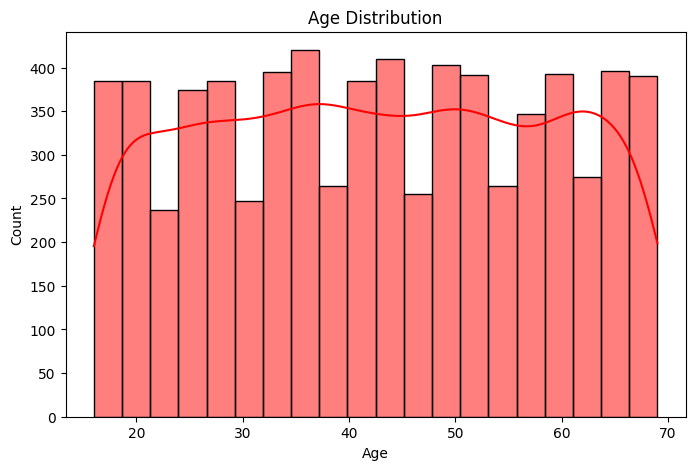

In [18]:
# Visualize the distribution of customer ages
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True,color="red")
plt.title('Age Distribution')
plt.show()

**Income Level**

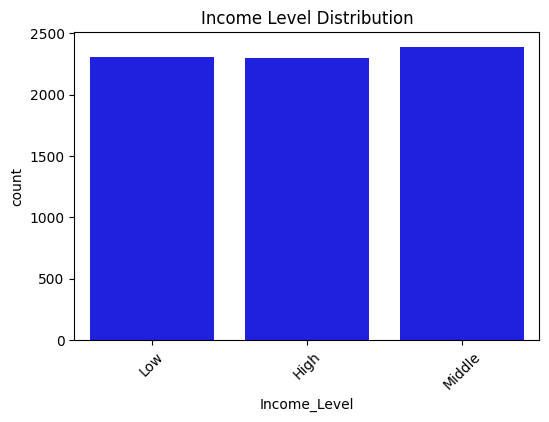

In [19]:
# Visualize the distribution of customers across income levels
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Income_Level',color="blue")
plt.title('Income Level Distribution')
plt.xticks(rotation=45)
plt.show()

**Preferred Payment Method**

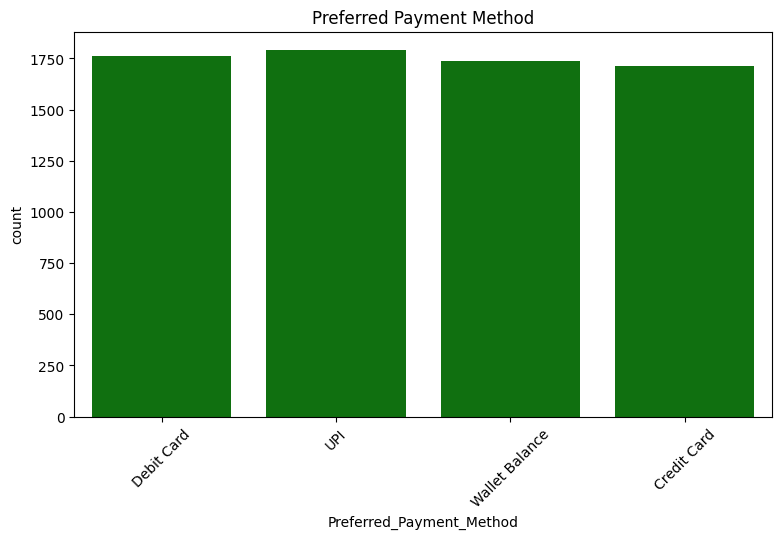

In [20]:
# Analyze customers' preferred payment methods
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Preferred_Payment_Method',color="green")
plt.title('Preferred Payment Method')
plt.xticks(rotation=45)
plt.show()

**Total Spent**

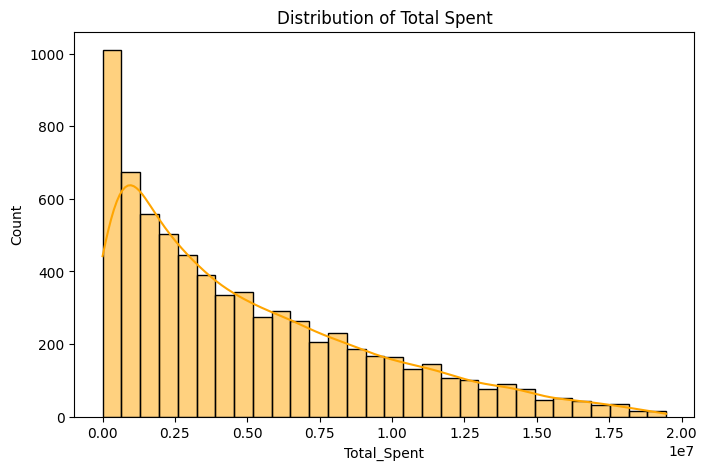

In [21]:
# Examine the distribution of customers' total spending
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Spent'], bins=30, kde=True,color="orange")
plt.title('Distribution of Total Spent')
plt.show()

**LTV Distribution**

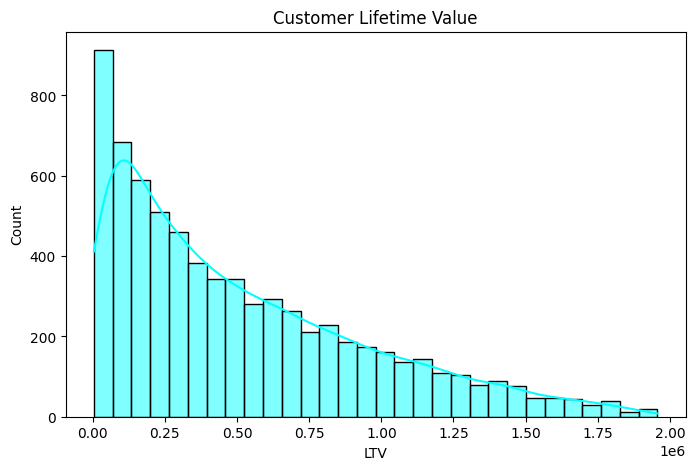

In [22]:
# Visualize customer lifetime va;ue
plt.figure(figsize=(8,5))
sns.histplot(df['LTV'], bins=30, kde=True,color="aqua")
plt.title('Customer Lifetime Value')
plt.show()

**Correlation Heatmap**

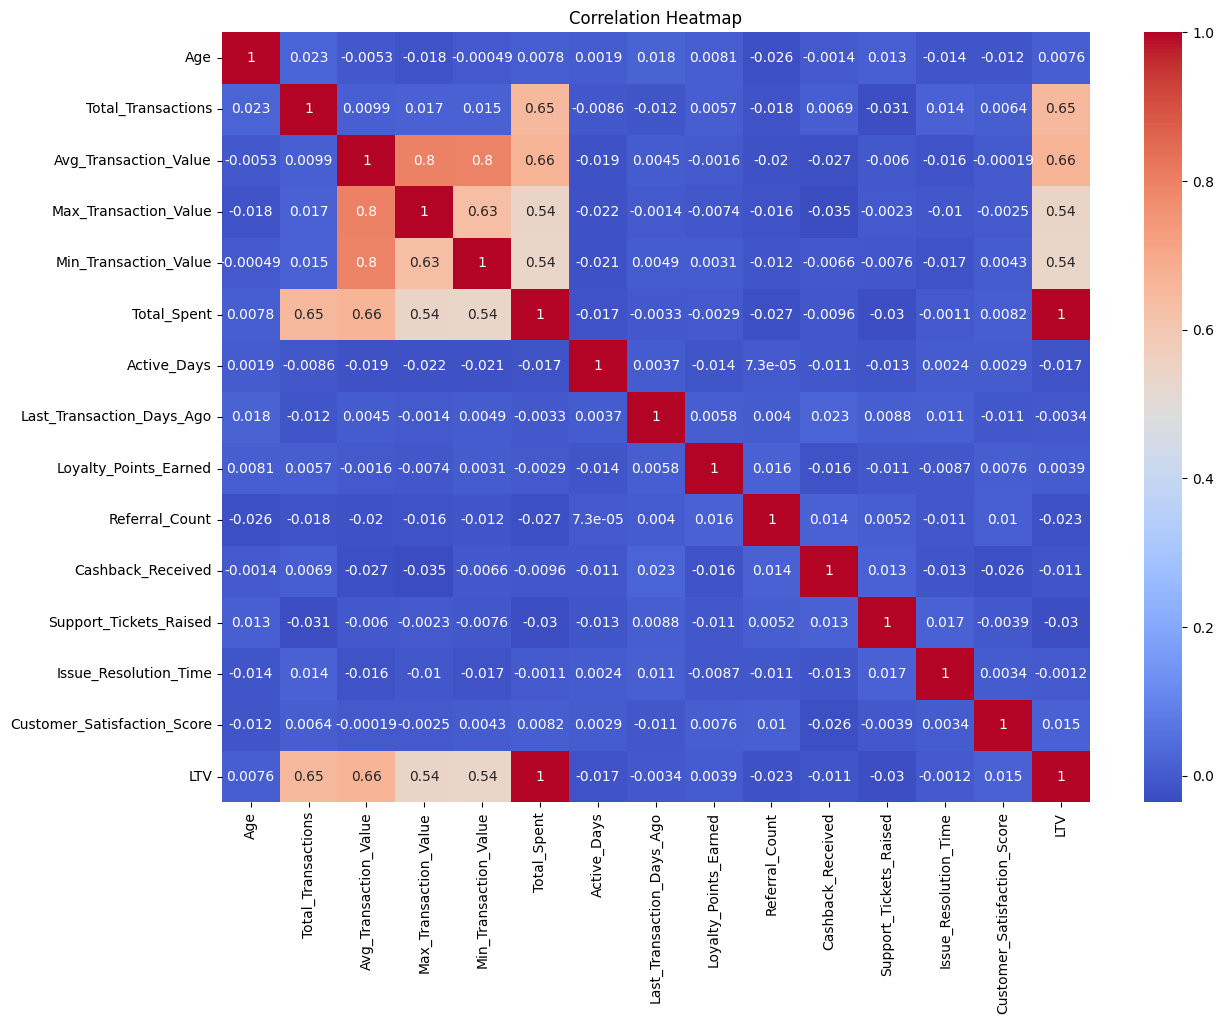

In [23]:
# Visualize correlations among numerical features
plt.figure(figsize=(14,10))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

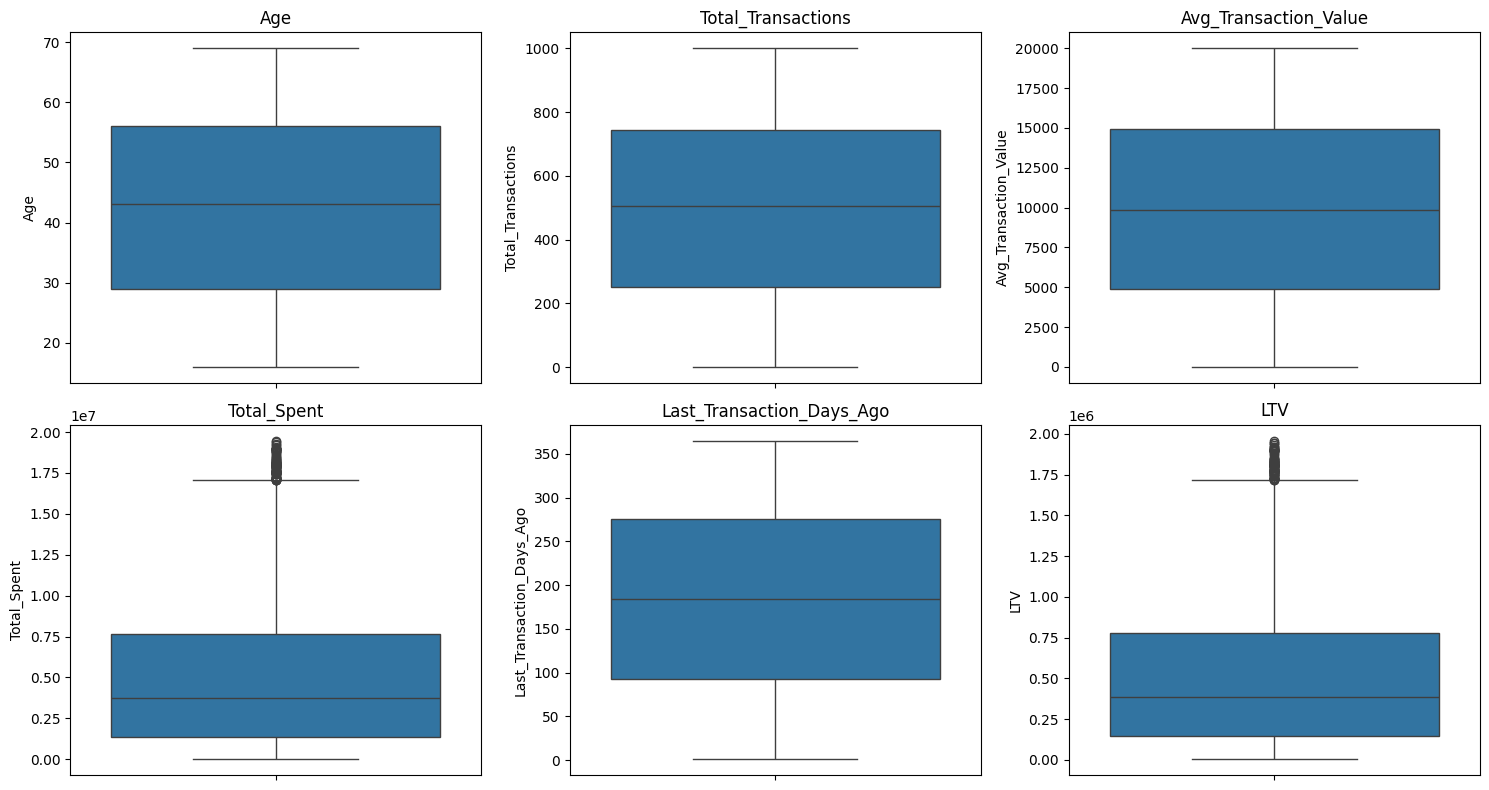

In [24]:
# Visualize key numerical features to identify potential outliers

numerical_features = [
    'Age',
    'Total_Transactions',
    'Avg_Transaction_Value',
    'Total_Spent',
    'Last_Transaction_Days_Ago',
    'LTV'
]

plt.figure(figsize=(15,8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

observation:

Although Total_Spent and LTV contain outliers, they are likely to represent genuine high-value customers rather than data errors. Therefore, these observations will be retained for K-Means clustering, as they provide valuable insights for identifying premium customer segments.



In [25]:
# Select behavioural features for customer segmentation.
# These variables represent customer purchase frequency,
# spending behaviour, recency of activity, and overall customer value,
# making them suitable for K-Means clustering.
features = df[['Total_Transactions',
               'Total_Spent',
               'Last_Transaction_Days_Ago',
               'LTV']]

# **Standardize the Features**

In [27]:
# Standardize the selected features before applying K-Means clustering.
# K-Means uses Euclidean distance to measure similarity between data points.
# Since features such as Total_Spent and Total_Transactions are on different
# scales, standardization ensures that each feature contributes equally to
# the clustering process and prevents features with larger values from
# dominating the distance calculations.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [28]:
# Determine the optimal number of clusters using the Elbow Method.
# WCSS (Within-Cluster Sum of Squares) measures how compact the clusters are.
# We compute WCSS for different values of K and select the value where the
# decrease in WCSS starts to level off (the "elbow" point).

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

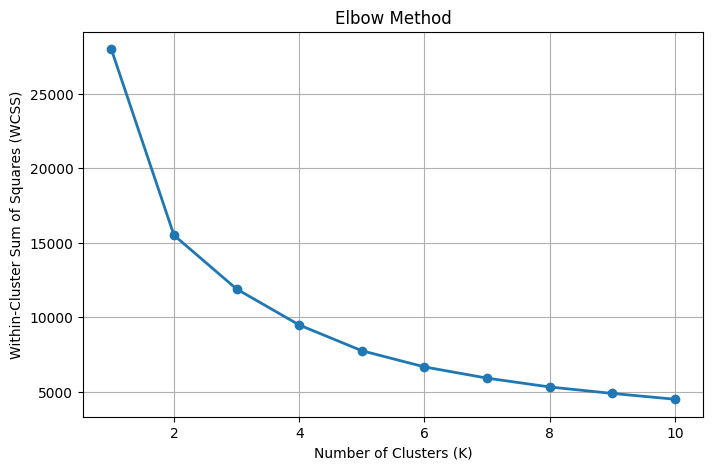

In [29]:
# Plot the Elbow Method graph.
# The optimal number of clusters is chosen at the point where increasing
# the number of clusters results in diminishing improvements in WCSS.

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.grid(True)

plt.show()

Observation:

 The Elbow Method suggests that the optimal number of clusters is 4.
The WCSS decreases rapidly until K = 4 and then starts to level off,
 indicating that additional clusters provide only marginal improvements
 in cluster compactness.

# **Apply K-Means Clustering**

In [30]:
# Apply K-Means clustering using the optimal number of clusters (K = 4).
# Each customer is assigned to the cluster with the nearest centroid
# based on the standardized RFM features and LTV.

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [31]:
# Display the number of customers in each cluster.
# This helps assess whether the clusters are reasonably balanced.

df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,2075
1,1429
2,1795
3,1701


In [32]:
# Calculate the average values of the selected features for each cluster.
# This helps understand the characteristics of each customer segment.

cluster_summary = df.groupby('Cluster')[features.columns].mean()

cluster_summary

,Total_Transactions,Total_Spent,Last_Transaction_Days_Ago,LTV
Cluster,,,,
0,436.355181,3.074230e+06,76.624578,3.192186e+05
1,794.586424,1.204104e+07,165.387684,1.215770e+06
2,194.387187,1.441961e+06,247.914763,1.558996e+05
3,657.686067,5.197040e+06,262.546737,5.313842e+05


In [33]:
# Assign business personas based on cluster characteristics identified
# from the cluster summary.

persona_mapping = {
    0: "Potential Loyal Customers",
    1: "Champions",
    2: "At-Risk Customers",
    3: "Loyal but Inactive Customers"
}

df['Customer_Persona'] = df['Cluster'].map(persona_mapping)

df[['Cluster', 'Customer_Persona']].head()

,Cluster,Customer_Persona
0,2,At-Risk Customers
1,1,Champions
2,0,Potential Loyal Customers
3,2,At-Risk Customers
4,3,Loyal but Inactive Customers


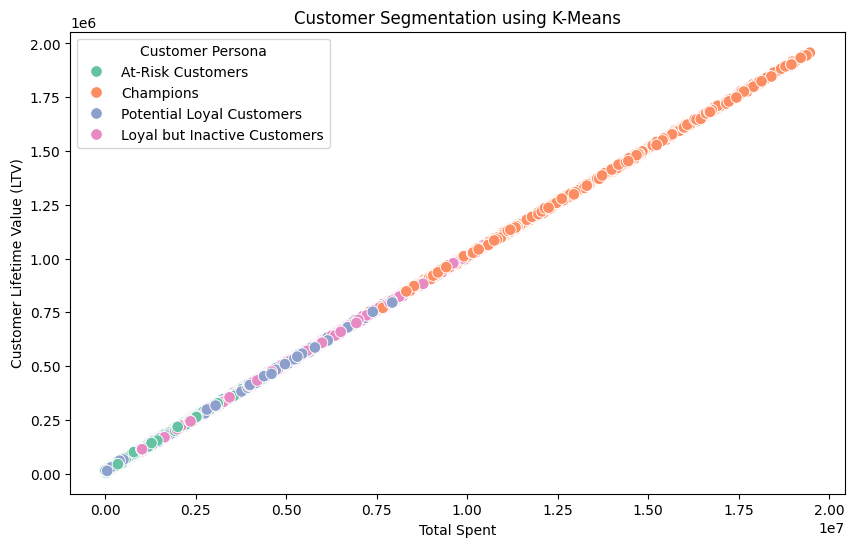

In [35]:
# Visualize customer segments based on Total Spent and Lifetime Value.
# Each color represents a different customer segment identified by K-Means.

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Total_Spent',
    y='LTV',
    hue='Customer_Persona',
    palette='Set2',
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Total Spent")
plt.ylabel("Customer Lifetime Value (LTV)")
plt.legend(title="Customer Persona")
plt.show()

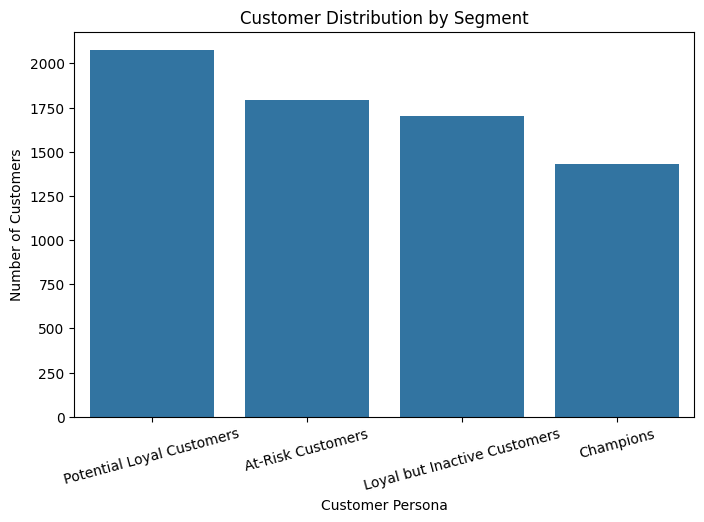

In [36]:
# Display the number of customers in each customer segment.

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Customer_Persona',
    order=df['Customer_Persona'].value_counts().index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

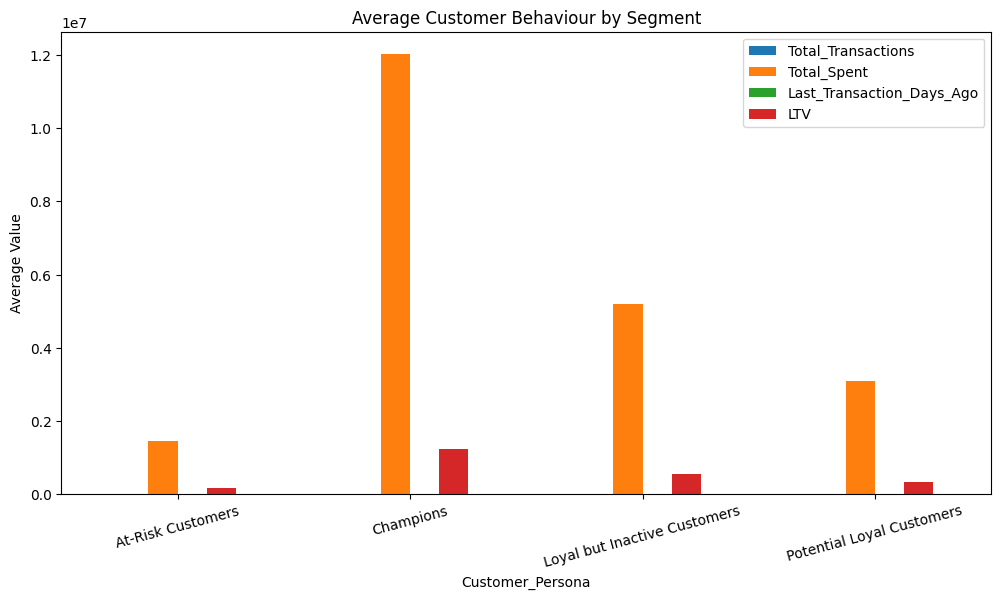

In [37]:
# Compare the average values of the selected features across customer segments.

cluster_summary = df.groupby('Customer_Persona')[[
    'Total_Transactions',
    'Total_Spent',
    'Last_Transaction_Days_Ago',
    'LTV'
]].mean()

cluster_summary.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Customer Behaviour by Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=15)

plt.show()

**Business Insights**

1.Champions:

-Highest transaction frequency and spending.

-Highest customer lifetime value.

-Focus on retention through premium rewards and exclusive benefits.

2.Potential Loyal Customers:

-Moderate spending with recent activity.

-Can be converted into loyal customers using personalized offers and loyalty programs.

3.Loyal but Inactive Customers:

-Previously valuable customers who have not transacted recently.

-Target with re-engagement campaigns and personalized promotions.

4.At-Risk Customers:

-Lowest spending, lowest transaction frequency, and lowest lifetime value.

-Use win-back campaigns and feedback collection to reduce churn.

## Conclusion

This project applied K-Means clustering to segment customers using RFM-based
features (Recency, Frequency, Monetary) along with Customer Lifetime Value (LTV).

The Elbow Method identified four optimal customer segments. Each segment
represents customers with distinct purchasing behaviours, enabling the business
to design targeted marketing strategies, improve customer retention, and
maximize customer lifetime value.

Customer segmentation provides actionable insights that help businesses allocate
resources more effectively and deliver personalized customer experiences.